In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ecg-data/mitbih_test.csv
/kaggle/input/ecg-data/mitbih_train.csv


In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, LSTM, Bidirectional, Dense, Dropout
)
from tensorflow.keras.optimizers import Adam


2026-01-24 17:38:07.874254: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769276288.085460      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769276288.140500      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769276288.612740      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769276288.612804      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769276288.612807      24 computation_placer.cc:177] computation placer alr

In [3]:
df = pd.read_csv("/kaggle/input/ecg-data/mitbih_train.csv", header=None)

print(df.shape)   # should be (87554, 188)


(87554, 188)


In [4]:
X = df.iloc[:, :-1].values    # shape: (samples, 187)
y = df.iloc[:, -1].values    # shape: (samples,)


In [5]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique labels:", np.unique(y))


X shape: (87554, 187)
y shape: (87554,)
Unique labels: [0. 1. 2. 3. 4.]


In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [7]:
def moving_average(signal, window=5):
    return np.convolve(signal, np.ones(window)/window, mode="same")

def create_ts_channels(signal):
    original = signal
    smooth = moving_average(signal)
    derivative = np.gradient(signal)

    # normalize each channel
    def norm(x):
        return (x - np.mean(x)) / (np.std(x) + 1e-8)

    return np.stack([
        norm(original),
        norm(smooth),
        norm(derivative)
    ], axis=1)


In [8]:
X_train_ts = np.array([create_ts_channels(x) for x in X_train])
X_val_ts   = np.array([create_ts_channels(x) for x in X_val])

print(X_train_ts.shape)


(70043, 187, 3)


In [9]:
print("X_train_ts shape:", X_train_ts.shape)
print("y_train shape:", y_train.shape)


X_train_ts shape: (70043, 187, 3)
y_train shape: (70043,)


In [10]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

# soften weights (VERY IMPORTANT)
class_weight_dict = {
    int(cls): float(wt ** 0.5)
    for cls, wt in zip(np.unique(y_train), class_weights)
}

print("Class weights:", class_weight_dict)


Class weights: {0: 0.49155203425853494, 1: 2.8069293976549488, 2: 1.7394296624916856, 3: 5.2256303424212405, 4: 1.6500787742187668}


In [11]:
model = Sequential([
    Input(shape=(187, 3)),

    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),

    Bidirectional(LSTM(64)),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dense(5, activation="softmax")
])


I0000 00:00:1769276318.160072      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [12]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 187, 128)       │        34,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 187, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,213 (555.52 KB)

 Trainable params: 142,213 (555.52 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train_ts, y_train,
    validation_data=(X_val_ts, y_val),
    epochs=20,
    batch_size=128,
    class_weight=class_weight_dict,
    verbose=1
)


Epoch 1/20


I0000 00:00:1769276323.737269      65 cuda_dnn.cc:529] Loaded cuDNN version 91002


548/548 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step - accuracy: 0.8823 - loss: 0.5738 - val_accuracy: 0.9531 - val_loss: 0.1977
Epoch 2/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.9384 - loss: 0.2725 - val_accuracy: 0.9431 - val_loss: 0.2251
Epoch 3/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.9445 - loss: 0.2325 - val_accuracy: 0.9629 - val_loss: 0.1367
Epoch 4/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.9523 - loss: 0.1964 - val_accuracy: 0.9651 - val_loss: 0.1189
Epoch 5/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.9501 - loss: 0.1853 - val_accuracy: 0.9587 - val_loss: 0.1427
Epoch 6/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.9572 - loss: 0.1667 - val_accuracy: 0.9561 - val_loss: 0.1413
Epoch 7/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.9617 - loss: 0.1454 - val_accuracy: 0.9719 - val_loss: 0.1027
Epoch 8/20
548/548 ━━━━━━━━━━━━━━━━━━━━ 27s 49ms/step - accuracy: 0.9640 - loss: 0.1341 - val_accurac

In [14]:
y_pred = np.argmax(model.predict(X_val_ts), axis=1)

print(classification_report(y_val, y_pred))


548/548 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99     14494
         1.0       0.72      0.88      0.79       445
         2.0       0.94      0.95      0.94      1158
         3.0       0.62      0.88      0.73       128
         4.0       0.98      0.99      0.98      1286

    accuracy                           0.98     17511
   macro avg       0.85      0.94      0.89     17511
weighted avg       0.98      0.98      0.98     17511



In [15]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Layer, Input, LSTM, Bidirectional,
    Dense, Dropout
)
from tensorflow.keras.models import Model


In [16]:
class TemporalAttention(Layer):
    def __init__(self):
        super().__init__()

    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="normal"
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1], 1),
            initializer="zeros"
        )

    def call(self, x):
        # x shape: (batch, timesteps, features)
        e = tf.tanh(tf.matmul(x, self.W) + self.b)
        a = tf.nn.softmax(e, axis=1)      # attention weights
        output = tf.reduce_sum(x * a, axis=1)
        return output, a


In [17]:
inputs = Input(shape=(187, 3))

# BiLSTM encoder
x = Bidirectional(LSTM(64, return_sequences=True))(inputs)
x = Dropout(0.3)(x)

x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.3)(x)

# Attention
context, attention_weights = TemporalAttention()(x)

# Dense layers
x = Dense(64, activation="relu")(context)
outputs = Dense(5, activation="softmax")(x)

model_att = Model(inputs, outputs)


In [18]:
def focal_loss(gamma=2., alpha=0.5):
    def loss(y_true, y_pred):
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=5)
        ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        pt = tf.reduce_sum(y_true * y_pred, axis=-1)
        fl = alpha * tf.pow(1. - pt, gamma) * ce
        return fl
    return loss

In [19]:
model_att.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=focal_loss(gamma=2, alpha=0.5),
    metrics=["accuracy"]
)

model_att.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 187, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 187, 128)       │        34,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 187, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 187, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 187, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ [(None, 128), (None,   │           315 │
│ (TemporalAttention)             │ 187, 1)]               │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,528 (556.75 KB)

 Trainable params: 142,528 (556.75 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history_att = model_att.fit(
    X_train_ts, y_train,
    validation_data=(X_val_ts, y_val),
    epochs=30,
    batch_size=128,
    verbose=1
)


Epoch 1/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 33s 54ms/step - accuracy: 0.8611 - loss: 0.1383 - val_accuracy: 0.9515 - val_loss: 0.0363
Epoch 2/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.9551 - loss: 0.0345 - val_accuracy: 0.9658 - val_loss: 0.0244
Epoch 3/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.9649 - loss: 0.0254 - val_accuracy: 0.9704 - val_loss: 0.0211
Epoch 4/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.9699 - loss: 0.0216 - val_accuracy: 0.9732 - val_loss: 0.0177
Epoch 5/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.9736 - loss: 0.0186 - val_accuracy: 0.9745 - val_loss: 0.0177
Epoch 6/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.9752 - loss: 0.0172 - val_accuracy: 0.9746 - val_loss: 0.0165
Epoch 7/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.9757 - loss: 0.0159 - val_accuracy: 0.9774 - val_loss: 0.0153
Epoch 8/30
548/548 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - accuracy: 0.9783 - loss: 0.0137 - 

In [21]:
from imblearn.over_sampling import RandomOverSampler

X_flat = X_train_ts.reshape(len(X_train_ts), -1)
ros = RandomOverSampler(sampling_strategy={1:3000, 3:1500})
X_res, y_res = ros.fit_resample(X_flat, y_train)

X_train_ts = X_res.reshape(-1, 187, 3)
y_train = y_res


In [22]:
y_pred = tf.argmax(model_att.predict(X_val_ts), axis=1).numpy()

from sklearn.metrics import classification_report
print(classification_report(y_val, y_pred))


548/548 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     14494
         1.0       0.91      0.76      0.83       445
         2.0       0.95      0.96      0.96      1158
         3.0       0.72      0.89      0.79       128
         4.0       0.99      0.99      0.99      1286

    accuracy                           0.98     17511
   macro avg       0.91      0.92      0.91     17511
weighted avg       0.98      0.98      0.98     17511



In [23]:
attention_model = Model(
    inputs=model_att.input,
    outputs=attention_weights
)


In [24]:
attention_model.save("ecg_attention_extractor.h5")

In [25]:
idx = 10  # try different classes
att_weights = attention_model.predict(
    X_val_ts[idx:idx+1]
)[0].squeeze()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step


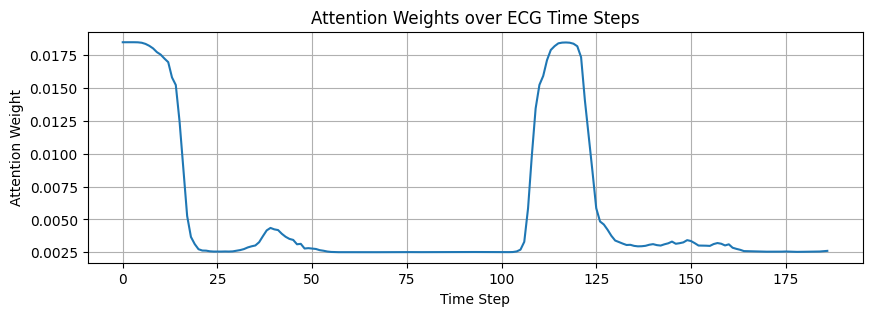

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))
plt.plot(att_weights)
plt.title("Attention Weights over ECG Time Steps")
plt.xlabel("Time Step")
plt.ylabel("Attention Weight")
plt.grid()
plt.show()


In [27]:
x_sample = X_val_ts[0:1]     # shape (1, 187, 3)

# Get predicted class
pred = model_att(x_sample)
target_class = tf.argmax(pred[0])

In [28]:
import tensorflow as tf

# 1️⃣ Make sure input is a Tensor
x_sample = tf.convert_to_tensor(X_val_ts[0:1], dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(x_sample)

    # 2️⃣ Forward pass
    preds = model_att(x_sample)

    # 3️⃣ Choose target class INSIDE the tape
    target_class = tf.argmax(preds[0])

    # 4️⃣ Select scalar loss
    loss = preds[:, target_class]

# 5️⃣ Compute gradients
grads = tape.gradient(loss, x_sample)

print(grads.shape)  # (1, 187, 3)


(1, 187, 3)


In [29]:
saliency = tf.abs(grads)[0]        # (187, 3)
saliency_1d = tf.reduce_mean(saliency, axis=1)  # (187,)
saliency_1d = saliency_1d.numpy()


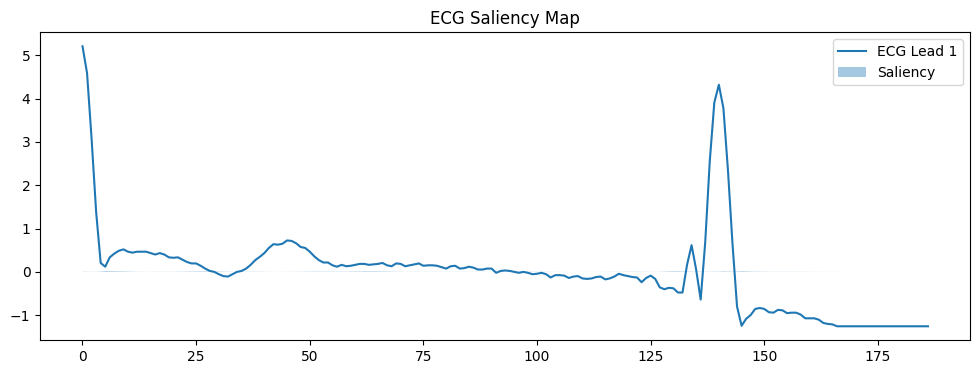

In [30]:
import matplotlib.pyplot as plt

time = np.arange(187)

plt.figure(figsize=(12,4))
plt.plot(time, x_sample[0,:,0], label="ECG Lead 1")
plt.fill_between(time, saliency_1d, alpha=0.4, label="Saliency")
plt.legend()
plt.title("ECG Saliency Map")
plt.show()


In [31]:
baseline = tf.zeros_like(x_sample)  # shape (1, 187, 3)
def integrated_gradients(
    model,
    x,
    baseline,
    target_class,
    steps=50
):
    """
    model: trained keras model
    x: input tensor (1, T, C)
    baseline: baseline tensor (1, T, C)
    target_class: class index tensor
    steps: number of integration steps
    """

    # 1️⃣ Generate scaled inputs
    alphas = tf.linspace(0.0, 1.0, steps+1)

    integrated_grads = tf.zeros_like(x)

    for alpha in alphas:
        x_interp = baseline + alpha * (x - baseline)

        with tf.GradientTape() as tape:
            tape.watch(x_interp)
            preds = model(x_interp, training=False)
            loss = preds[:, target_class]

        grads = tape.gradient(loss, x_interp)
        integrated_grads += grads

    # 2️⃣ Average gradients and scale
    integrated_grads /= tf.cast(steps + 1, tf.float32)
    integrated_grads *= (x - baseline)

    return integrated_grads


In [32]:
# Make sure input is a tensor
x_sample = tf.convert_to_tensor(X_val_ts[0:1], dtype=tf.float32)

# Get prediction & target class
preds = model_att(x_sample, training=False)
target_class = tf.argmax(preds[0])

# Compute Integrated Gradients
ig = integrated_gradients(
    model=model_att,
    x=x_sample,
    baseline=baseline,
    target_class=target_class,
    steps=50
)


In [33]:
ig_abs = tf.abs(ig)[0]                 # (187, 3)
ig_time = tf.reduce_mean(ig_abs, axis=1)  # (187,)


In [34]:
ig_channel = tf.reduce_mean(ig_abs, axis=0)
print("Channel importance:", ig_channel.numpy())


Channel importance: [0.00271387 0.00320102 0.00585295]


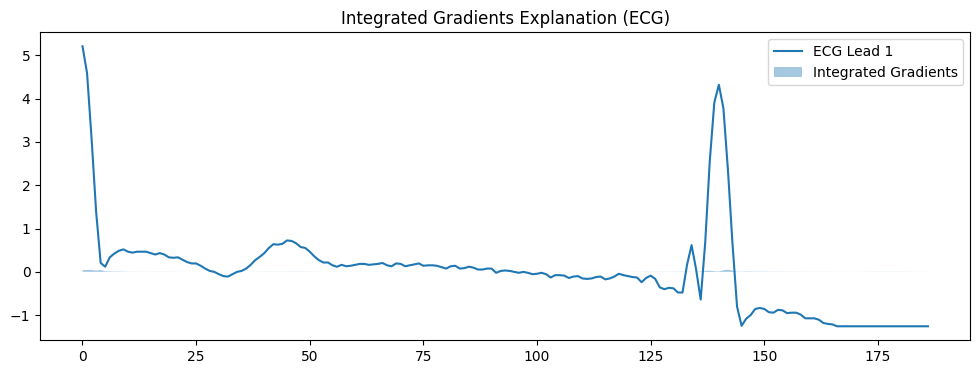

In [35]:
import matplotlib.pyplot as plt
import numpy as np

time = np.arange(187)

plt.figure(figsize=(12,4))
plt.plot(time, x_sample[0,:,0], label="ECG Lead 1")
plt.fill_between(time, ig_time.numpy(), alpha=0.4, label="Integrated Gradients")
plt.legend()
plt.title("Integrated Gradients Explanation (ECG)")
plt.show()


In [36]:
# Get attention weights
attention_model = tf.keras.Model(
    inputs=model_att.input,
    outputs=attention_weights
)

attn = attention_model(x_sample).numpy().squeeze()  # (187,)

# Attention-weighted IG
ig_weighted = ig_time.numpy() * attn


In [37]:
import numpy as np
saliency_1d = np.array(saliency_1d)
saliency_norm = saliency_1d / (saliency_1d.max() + 1e-8)

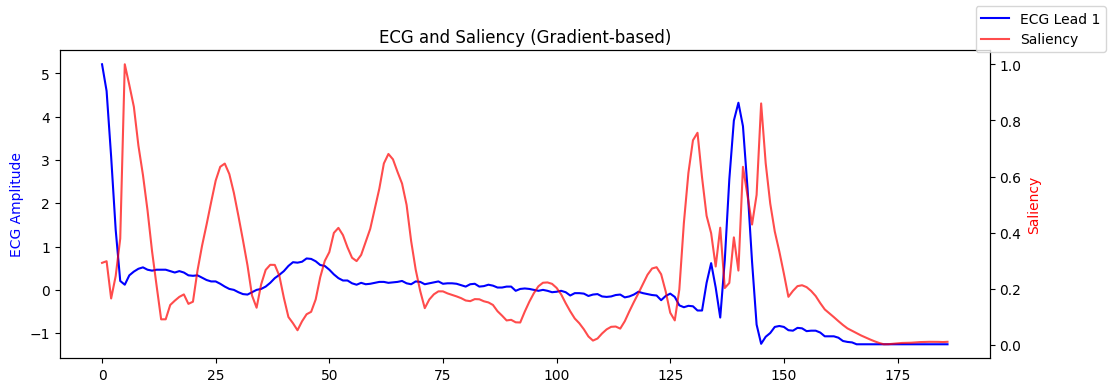

In [38]:
fig, ax1 = plt.subplots(figsize=(12,4))

# ECG
ax1.plot(time, x_sample[0,:,0], color="blue", label="ECG Lead 1")
ax1.set_ylabel("ECG Amplitude", color="blue")

# Saliency
ax2 = ax1.twinx()
ax2.plot(time, saliency_norm, color="red", alpha=0.7, label="Saliency")
ax2.set_ylabel("Saliency", color="red")

fig.legend(loc="upper right")
plt.title("ECG and Saliency (Gradient-based)")
plt.show()


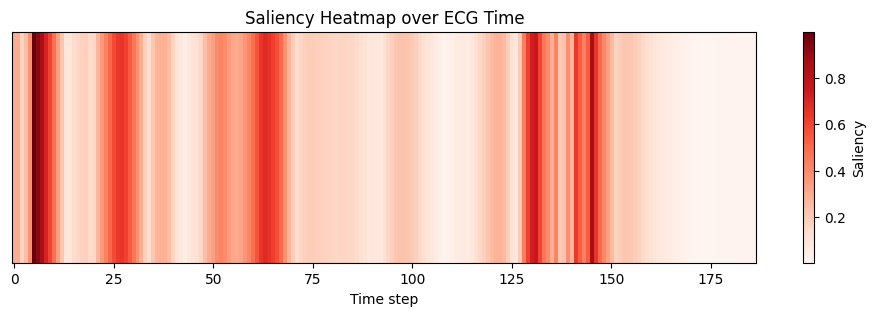

In [39]:
plt.figure(figsize=(12,3))
plt.imshow(
    saliency_norm[np.newaxis, :],
    aspect="auto",
    cmap="Reds"
)
plt.yticks([])
plt.xlabel("Time step")
plt.title("Saliency Heatmap over ECG Time")
plt.colorbar(label="Saliency")
plt.show()


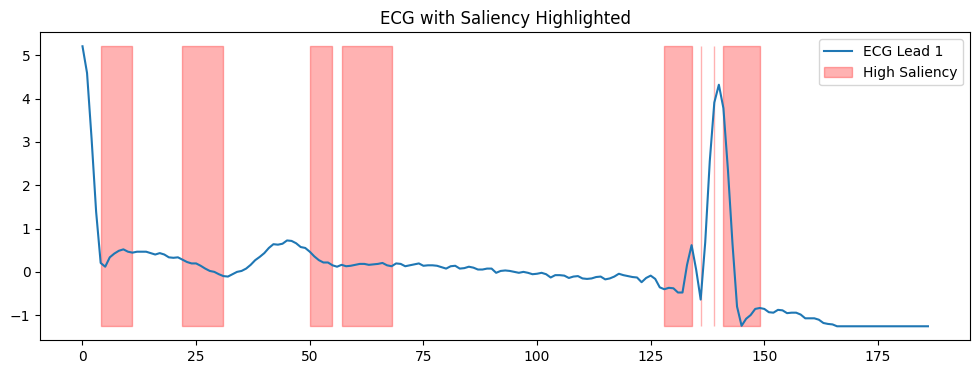

In [40]:
saliency_norm = saliency_1d / (saliency_1d.max() + 1e-8)

plt.figure(figsize=(12,4))
plt.plot(time, x_sample[0,:,0], label="ECG Lead 1")

plt.fill_between(
    time,
    y1=min(x_sample[0,:,0]),
    y2=max(x_sample[0,:,0]),
    where=saliency_norm > 0.3,
    color="red",
    alpha=0.3,
    label="High Saliency"
)

plt.legend()
plt.title("ECG with Saliency Highlighted")
plt.show()


In [41]:
test_df = pd.read_csv("/kaggle/input/ecg-data/mitbih_test.csv", header=None)

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

print("Raw Test Shape:", X_test.shape)


X_test_ts = np.array([create_ts_channels(x) for x in X_test])
print("Processed Test Shape:", X_test_ts.shape)



y_pred_test = np.argmax(model_att.predict(X_test_ts), axis=1)



from sklearn.metrics import classification_report, confusion_matrix

print("\n=== Classification Report (TEST SET) ===")
print(classification_report(y_test, y_pred_test))

print("\n=== Confusion Matrix (TEST SET) ===")
print(confusion_matrix(y_test, y_pred_test))

Raw Test Shape: (21892, 187)
Processed Test Shape: (21892, 187, 3)
685/685 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step

=== Classification Report (TEST SET) ===
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     18118
         1.0       0.93      0.73      0.82       556
         2.0       0.95      0.95      0.95      1448
         3.0       0.71      0.90      0.79       162
         4.0       0.99      0.99      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.92      0.91      0.91     21892
weighted avg       0.98      0.98      0.98     21892


=== Confusion Matrix (TEST SET) ===
[[18012    25    45    26    10]
 [  138   407     8     2     1]
 [   33     4  1377    31     3]
 [    9     0     8   145     0]
 [    9     0     4     0  1595]]
